# Game Week Points Prediction Notebook

This notebook trains an ML model to perform predictions on the number of points a player is predicted to achieve during the next gameweek. The data used in the project was pulled from the [Fantasy Premier League Repo](https://github.com/vaastav/Fantasy-Premier-League/tree/master).

## Load Data

First we will need to load the data used for the project as well as the libraries required for the project.


In [16]:
import random

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import optuna

from optuna.samplers import TPESampler

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer
from sklearn.metrics import mean_squared_error, make_scorer

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

In [17]:
data = pd.read_csv("data/cleaned_merged_seasons.csv")
data

/var/folders/hp/w5vg0y7x77zbv7sz16c4thsh0000gn/T/ipykernel_15475/2434492638.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/cleaned_merged_seasons.csv")


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,NaN,0,0,0,0,0.0,454,...,2.0,0.0,0,0,0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,NaN,0,0,6,0,0.3,142,...,1.0,0.0,1,0,0,0,60,True,0,1
2,2016-17,Aaron Ramsey,MID,NaN,0,0,5,0,4.9,16,...,3.0,23.0,2,0,0,0,80,True,0,1
3,2016-17,Abdoulaye Doucouré,MID,NaN,0,0,0,0,0.0,482,...,1.0,0.0,0,0,0,0,50,False,0,1
4,2016-17,Abdul Rahman Baba,DEF,NaN,0,0,0,0,0.0,80,...,2.0,0.0,0,0,0,0,55,True,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126071,2023-24,Kyle Walker,DEF,Man City,0,0,15,0,11.6,369,...,3.0,0.0,2,-3560,44071,47631,55,True,0,38
126072,2023-24,Jacob Brown,FWD,Luton,0,0,0,0,0.0,631,...,2.0,0.0,0,86,216,130,49,True,0,38
126073,2023-24,Vicente Guaita,GK,Crystal Palace,0,0,0,0,0.0,227,...,5.0,0.0,0,-120,0,120,44,True,0,38
126074,2023-24,Braian Ojeda Rodríguez,MID,Nott'm Forest,0,0,0,0,0.0,459,...,1.0,0.0,0,-1,0,1,45,False,0,38


In [18]:
data_agg = pd.read_csv("data/cleaned_merged_seasons_team_aggregated.csv")
data_agg = pd.get_dummies(data_agg, columns=["position", "team_x", "opp_team_name"])
data_agg

/var/folders/hp/w5vg0y7x77zbv7sz16c4thsh0000gn/T/ipykernel_15475/50134801.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data_agg = pd.read_csv("data/cleaned_merged_seasons_team_aggregated.csv")


,season_x,name,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,...,opp_team_name_Sheffield Utd,opp_team_name_Southampton,opp_team_name_Spurs,opp_team_name_Stoke,opp_team_name_Sunderland,opp_team_name_Swansea,opp_team_name_Watford,opp_team_name_West Brom,opp_team_name_West Ham,opp_team_name_Wolves
0,2016-17,Aaron Cresswell,0,0,0,0,0.0,454,10,0,...,False,False,False,False,False,False,False,False,False,False
1,2016-17,Aaron Lennon,0,0,6,0,0.3,142,3,0,...,False,False,True,False,False,False,False,False,False,False
2,2016-17,Aaron Ramsey,0,0,5,0,4.9,16,8,3,...,False,False,False,False,False,False,False,False,False,False
3,2016-17,Abdoulaye Doucouré,0,0,0,0,0.0,482,7,0,...,False,True,False,False,False,False,False,False,False,False
4,2016-17,Abdul Rahman Baba,0,0,0,0,0.0,80,10,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126071,2023-24,Kyle Walker,0,0,15,0,11.6,369,379,1,...,False,False,False,False,False,False,False,False,True,False
126072,2023-24,Jacob Brown,0,0,0,0,0.0,631,378,0,...,False,False,False,False,False,False,False,False,False,False
126073,2023-24,Vicente Guaita,0,0,0,0,0.0,227,376,0,...,False,False,False,False,False,False,False,False,False,False
126074,2023-24,Braian Ojeda Rodríguez,0,0,0,0,0.0,459,374,0,...,False,False,False,False,False,False,False,False,False,False


In [19]:
season_data = data_agg.groupby(
        ["season_x", "name"],
    ).agg(
        {
            "yellow_cards": "sum",
            "red_cards": "sum",
            "assists": "sum",
            "own_goals": "sum",
            "penalties_saved": "sum",
            "penalties_missed": "sum",
            "goals_scored": "sum",
            "goals_conceded": "sum",
            "total_points": "sum",
            "clean_sheets": "sum",
            "minutes": "sum",
            "ict_index": "mean",
            "influence": "mean",
        }
    ).reset_index().sort_values("season_x")
season_data["last_season"] = season_data.groupby("name").season_x.shift(-1)

season_data

,season_x,name,yellow_cards,red_cards,assists,own_goals,penalties_saved,penalties_missed,goals_scored,goals_conceded,total_points,clean_sheets,minutes,ict_index,influence,last_season
0,2016-17,Aaron Cresswell,2,1,2,0,0,0,0,35,60,5,2115,1.873684,8.094737,2017-18
157,2016-17,Manuel Lanzini,9,0,3,0,0,0,8,53,133,9,2708,5.618421,16.815789,2017-18
158,2016-17,Marc Albrighton,5,0,6,0,0,0,2,47,95,8,2412,3.884211,12.731579,2017-18
159,2016-17,Marcos Alonso,2,0,5,0,0,0,6,19,177,15,2693,4.502857,17.662857,2017-18
160,2016-17,Marcos Rojo,5,0,0,0,0,0,1,13,77,8,1663,1.750000,11.747368,2017-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3082,2023-24,Gonzalo Montiel,5,0,2,0,0,0,0,11,28,1,796,0.886111,4.738889,NaN
3083,2023-24,Gonçalo Manuel Ganchinho Guedes,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,NaN
3084,2023-24,Granit Xhaka,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,NaN
3073,2023-24,Gavin Kilkenny,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,NaN


In [20]:
value_cols = ["goals_scored", 
              "assists", 
              "clean_sheets", 
              "yellow_cards", 
              "red_cards", 
              "minutes", 
              "own_goals", 
              "penalties_saved", 
              "penalties_missed", 
              "goals_conceded",
              "total_points"]

data_agg[[f"{c}_cum_prior" for c in value_cols]] = (
    data_agg.groupby("season_x")[value_cols]
      .cumsum()
      .shift(1)
      .fillna(0)
)

data_agg.rename(columns=lambda x: x.strip().replace("'", ""), inplace=True)
data_agg

,season_x,name,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,...,assists_cum_prior,clean_sheets_cum_prior,yellow_cards_cum_prior,red_cards_cum_prior,minutes_cum_prior,own_goals_cum_prior,penalties_saved_cum_prior,penalties_missed_cum_prior,goals_conceded_cum_prior,total_points_cum_prior
0,2016-17,Aaron Cresswell,0,0,0,0,0.0,454,10,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2016-17,Aaron Lennon,0,0,6,0,0.3,142,3,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2016-17,Aaron Ramsey,0,0,5,0,4.9,16,8,3,...,0.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,1.0
3,2016-17,Abdoulaye Doucouré,0,0,0,0,0.0,482,7,0,...,0.0,0.0,0.0,0.0,75.0,0.0,0.0,0.0,3.0,3.0
4,2016-17,Abdul Rahman Baba,0,0,0,0,0.0,80,10,0,...,0.0,0.0,0.0,0.0,75.0,0.0,0.0,0.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126071,2023-24,Kyle Walker,0,0,15,0,11.6,369,379,1,...,1071.0,1903.0,1594.0,58.0,748540.0,50.0,8.0,11.0,13705.0,31269.0
126072,2023-24,Jacob Brown,0,0,0,0,0.0,631,378,0,...,1071.0,1903.0,1594.0,58.0,748630.0,50.0,8.0,11.0,13706.0,31271.0
126073,2023-24,Vicente Guaita,0,0,0,0,0.0,227,376,0,...,1071.0,1903.0,1594.0,58.0,748630.0,50.0,8.0,11.0,13706.0,31271.0
126074,2023-24,Braian Ojeda Rodríguez,0,0,0,0,0.0,459,374,0,...,1071.0,1903.0,1594.0,58.0,748630.0,50.0,8.0,11.0,13706.0,31271.0


In [21]:
final_data = data_agg.merge(season_data, left_on=["season_x", "name"], right_on=["last_season", "name"], how="left")

In [22]:
final_data = final_data.iloc[:, list(range(2)) + list(range(38, final_data.shape[1])) + list([26])]
final_data.drop(columns=["season_x_y", "last_season"], inplace=True)
final_data

,season_x_x,name,position_DEF,position_FWD,position_GK,position_GKP,position_MID,team_x_Arsenal,team_x_Aston Villa,team_x_Bournemouth,...,penalties_saved_y,penalties_missed_y,goals_scored_y,goals_conceded_y,total_points_y,clean_sheets_y,minutes_y,ict_index_y,influence_y,total_points_x
0,2016-17,Aaron Cresswell,True,False,False,False,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2016-17,Aaron Lennon,False,False,False,False,True,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2016-17,Aaron Ramsey,False,False,False,False,True,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,2016-17,Abdoulaye Doucouré,False,False,False,False,True,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2016-17,Abdul Rahman Baba,True,False,False,False,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126071,2023-24,Kyle Walker,True,False,False,False,False,False,False,False,...,0.0,0.0,0.0,20.0,69.0,7.0,1953.0,1.152632,5.889474,2
126072,2023-24,Jacob Brown,False,True,False,False,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
126073,2023-24,Vicente Guaita,False,False,True,False,False,False,False,False,...,0.0,0.0,0.0,34.0,99.0,6.0,2430.0,1.757895,17.589474,0
126074,2023-24,Braian Ojeda Rodríguez,False,False,False,False,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0


## Train ML Model

Now we have the final dataframe and features, we can begin to train a model to predict the number of points achieved in the next game.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


random.seed(445)

STORAGE = "sqlite:///db.sqlite3"

In [24]:
X_train, X_test, y_train, y_test = train_test_split(final_data.iloc[:, 2:89], final_data["total_points_x"] ,
                                   test_size=0.25, 
                                   shuffle=True)

### Linear Regression

First we'll train a simple linear regression as a baseline model

In [25]:
regression_model = LinearRegression()
regression_model.fit(X_train.fillna(0), y_train)

y_preds = regression_model.predict(X_test.fillna(0))

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error, median_absolute_error, r2_score, explained_variance_score
import numpy as np


def regression_report(y_true, y_pred):
    
    error = y_true - y_pred
    percentil = [5,25,50,75,95]
    percentil_value = np.percentile(error, percentil)
    
    metrics = [
        ('mean absolute error', mean_absolute_error(y_true, y_pred)),
        ('median absolute error', median_absolute_error(y_true, y_pred)),
        ('mean squared error', mean_squared_error(y_true, y_pred)),
        ('max error', max_error(y_true, y_pred)),
        ('r2 score', r2_score(y_true, y_pred)),
        ('explained variance score', explained_variance_score(y_true, y_pred))
    ]
    
    print('Metrics for regression:')
    for metric_name, metric_value in metrics:
        print(f'{metric_name:>25s}: {metric_value: >20.3f}')
        
    print('\nPercentiles:')
    for p, pv in zip(percentil, percentil_value):
        print(f'{p: 25d}: {pv:>20.3f}')

In [27]:
regression_report(y_test, y_preds)

Metrics for regression:
      mean absolute error:                1.508
    median absolute error:                0.943
       mean squared error:                5.748
                max error:               23.219
                 r2 score:                0.084
 explained variance score:                0.084

Percentiles:
                        5:               -2.121
                       25:               -1.113
                       50:               -0.691
                       75:                0.169
                       95:                5.249


Text(0.5, 0, 'Point Prediction Error')

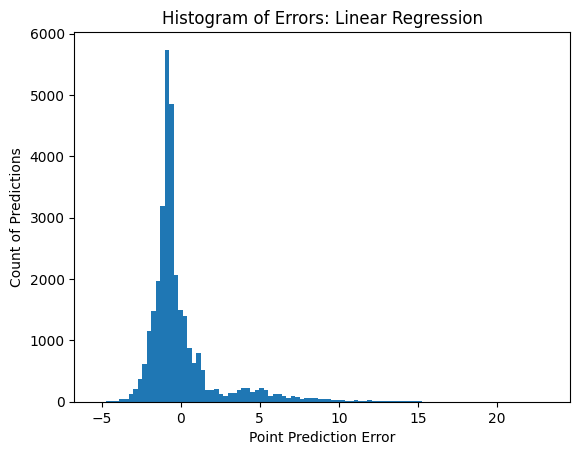

In [28]:
plt.hist(y_test - y_preds, bins=100)
plt.title("Histogram of Errors: Linear Regression")
plt.ylabel("Count of Predictions")
plt.xlabel("Point Prediction Error")

### LASSO Regression

Next, we'll train a LASSO regression model with hyper parameter tuning.

In [29]:
X_train, X_validate, y_train, y_validate = train_test_split(X_train.fillna(0), 
                                                            y_train,
                                                            test_size=0.25, 
                                                            shuffle=True)


def ridge_objective(trial):
    model = Ridge(
        alpha=trial.suggest_float("alpha", 1e-3, 100, log=True),
        max_iter=trial.suggest_int("max_iter", 10, 1000),
        tol=trial.suggest_float("tol", 0.00001, 0.9999, log=True),
        solver=trial.suggest_categorical("solver", ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'])
    )
    model.fit(X_train, y_train)
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_validate,
        y_validate,
        cv=5,
        scoring=make_scorer(mean_squared_error, greater_is_better=False),
        n_jobs=1
    )

    return abs(scores.mean())


# ----------------------------
# Run optimization
# ----------------------------
sampler = TPESampler(n_startup_trials=50)
study = optuna.create_study(study_name="ridge_trial", direction="minimize", storage=STORAGE, sampler=sampler)
study.optimize(ridge_objective, n_trials=300, show_progress_bar=True)

print("Best score:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-01-11 22:26:56,161] A new study created in RDB with name: ridge_trial
Best trial: 0. Best value: 5.44278:   0%|          | 1/300 [00:01<07:15,  1.46s/it]

[I 2026-01-11 22:26:57,611] Trial 0 finished with value: 5.4427840859824475 and parameters: {'alpha': 5.531174675701386, 'max_iter': 156, 'tol': 1.7488917312692415e-05, 'solver': 'svd'}. Best is trial 0 with value: 5.4427840859824475.


Best trial: 0. Best value: 5.44278:   1%|          | 2/300 [00:02<04:55,  1.01it/s]

[I 2026-01-11 22:26:58,283] Trial 1 finished with value: 5.442797705883952 and parameters: {'alpha': 6.865804852732114, 'max_iter': 887, 'tol': 0.00036231762020511065, 'solver': 'cholesky'}. Best is trial 0 with value: 5.4427840859824475.


Best trial: 2. Best value: 5.44255:   1%|          | 3/300 [00:03<05:50,  1.18s/it]

...

[I 2026-01-11 22:48:11,832] Trial 297 finished with value: 5.44270324473696 and parameters: {'alpha': 44.19963979447474, 'max_iter': 613, 'tol': 0.010170818459358457, 'solver': 'sag'}. Best is trial 267 with value: 5.442158478064952.


Best trial: 267. Best value: 5.44216: 100%|█████████▉| 299/300 [21:16<00:04,  4.02s/it]

[I 2026-01-11 22:48:12,511] Trial 298 finished with value: 5.442547524160885 and parameters: {'alpha': 77.83942573259107, 'max_iter': 570, 'tol': 0.0071907645426695, 'solver': 'auto'}. Best is trial 267 with value: 5.442158478064952.


Best trial: 267. Best value: 5.44216: 100%|██████████| 300/300 [21:18<00:00,  4.26s/it]

[I 2026-01-11 22:48:14,486] Trial 299 finished with value: 5.442986821589983 and parameters: {'alpha': 80.92073234873585, 'max_iter': 526, 'tol': 0.02403082914487182, 'solver': 'sag'}. Best is trial 267 with value: 5.442158478064952.
Best score: 5.442158478064952
Best params:
  alpha: 99.32252523600395
  max_iter: 530
  tol: 0.015739845390079055
  solver: sag


### Ridge Regression

Next, we'll train a ridge regression model

In [30]:
def ridge_objective(trial):
    model = Lasso(
            alpha=trial.suggest_float("alpha", 1e-3, 10, log=True),
            tol=trial.suggest_float("tol", 0.00001, 0.99999),
            max_iter=trial.suggest_int("max_iter", 10, 1000),
            selection=trial.suggest_categorical("selection", ['cyclic', 'random'])
        )
    
    model.fit(X_train, y_train)


    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_validate,
        y_validate,
        cv=5,
        scoring=make_scorer(mean_squared_error, greater_is_better=False),
        n_jobs=1
    )

    return abs(scores.mean())


# ----------------------------
# Run optimization
# ----------------------------
sampler = TPESampler(n_startup_trials=50)
study = optuna.create_study(study_name="lasso_trial", direction="minimize", storage=STORAGE, sampler=sampler)
study.optimize(ridge_objective, n_trials=300, show_progress_bar=True)

print("Best score:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-01-11 22:48:14,551] A new study created in RDB with name: lasso_trial
  0%|          | 0/300 [00:00<?, ?it/s]/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.057e+05, tolerance: 4.552e+04
  model = cd_fast.enet_coordinate_descent(
Best trial: 0. Best value: 5.94052:   0%|          | 1/300 [00:02<12:52,  2.58s/it]

[I 2026-01-11 22:48:17,129] Trial 0 finished with value: 5.94051739054658 and parameters: {'alpha': 0.48881617101747776, 'tol': 0.10284847911941106, 'max_iter': 640, 'selection': 'cyclic'}. Best is trial 0 with value: 5.94051739054658.


/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.055e+05, tolerance: 3.798e+04
  model = cd_fast.enet_coordinate_descent(
Best trial: 1. Best value: 5.66452:   1%|          | 2/300 [00:06<16:48,  3.38s/it]

[I 2026-01-11 22:48:21,068] Trial 1 finished with value: 5.664520413465875 and parameters: {'alpha': 0.2380077289572642, 'tol': 0.08581491078863716, 'max_iter': 792, 'selection': 'random'}. Best is trial 1 with value: 5.664520413465875.


Best trial: 1. Best value: 5.66452:   1%|          | 3/300 [00:07<10:55,  2.21s/it]

...

[I 2026-01-11 23:10:10,865] Trial 297 finished with value: 5.443038629376266 and parameters: {'alpha': 0.001002904627414264, 'tol': 0.05897166430440921, 'max_iter': 110, 'selection': 'cyclic'}. Best is trial 108 with value: 5.442837793018337.


/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.038e+05, tolerance: 4.191e+04
  model = cd_fast.enet_coordinate_descent(
/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.392e+04, tolerance: 1.052e+04
  model = cd_fast.enet_coordinate_descent(
/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

[I 2026-01-11 23:10:13,168] Trial 298 finished with value: 5.443107397239972 and parameters: {'alpha': 0.0011608562133685713, 'tol': 0.09470342423027907, 'max_iter': 109, 'selection': 'cyclic'}. Best is trial 108 with value: 5.442837793018337.


/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.043e+05, tolerance: 2.218e+04
  model = cd_fast.enet_coordinate_descent(
/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.734e+04, tolerance: 5.568e+03
  model = cd_fast.enet_coordinate_descent(
/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

[I 2026-01-11 23:10:14,033] Trial 299 finished with value: 5.460129370346953 and parameters: {'alpha': 0.0010145660825921653, 'tol': 0.050116830972235585, 'max_iter': 10, 'selection': 'cyclic'}. Best is trial 108 with value: 5.442837793018337.
Best score: 5.442837793018337
Best params:
  alpha: 0.0011747247241884
  tol: 0.10464964569659434
  max_iter: 818
  selection: random


### Random Forest Regression

Then we'll train a RF Regression model and hyperparameter tune using Optuna.

In [31]:
def rf_objective(trial):
    model = RandomForestRegressor(n_estimators=trial.suggest_int("n_estimators", 100, 1000),
                                  max_depth=trial.suggest_int("max_depth", 3, 300),
                                  min_samples_split=trial.suggest_int("min_samples_split", 2, 1200),
                                  min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 1200),
                                  max_features=trial.suggest_int("max_features", 1, 800),
                                  min_impurity_decrease=trial.suggest_float("min_impurity", 0.0, 0.9999),
                                  random_state=42,
                                  n_jobs=1
                                 )
    
    model.fit(X_train, y_train)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_validate,
        y_validate,
        cv=5,
        scoring=make_scorer(mean_squared_error, greater_is_better=False),
        n_jobs=1
    )

    return abs(scores.mean())

sampler = TPESampler(n_startup_trials=50)
study = optuna.create_study(study_name="rf_trial", direction="minimize", storage=STORAGE, sampler=sampler)
study.optimize(rf_objective, n_trials=120, show_progress_bar=True)

print("Best score:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-01-11 23:10:14,102] A new study created in RDB with name: rf_trial
Best trial: 0. Best value: 5.94051:   1%|          | 1/120 [01:03<2:06:12, 63.64s/it]

[I 2026-01-11 23:11:17,732] Trial 0 finished with value: 5.940513972870581 and parameters: {'n_estimators': 567, 'max_depth': 231, 'min_samples_split': 899, 'min_samples_leaf': 661, 'max_features': 337, 'min_impurity': 0.5185639614997815}. Best is trial 0 with value: 5.940513972870581.


Best trial: 1. Best value: 5.94051:   2%|▏         | 2/120 [02:14<2:13:43, 67.99s/it]

[I 2026-01-11 23:12:28,779] Trial 1 finished with value: 5.940513367157861 and parameters: {'n_estimators': 627, 'max_depth': 230, 'min_samples_split': 540, 'min_samples_leaf': 572, 'max_features': 92, 'min_impurity': 0.3699004623917316}. Best is trial 1 with value: 5.940513367157861.


Best trial: 2. Best value: 5.94051:   2%|▎         | 3/120 [02:59<1:51:53, 57.38s/it]

...

Best trial: 24. Best value: 5.4977:  28%|██▊       | 33/120 [1:00:01<2:27:14, 101.54s/it]

[I 2026-01-12 00:10:15,762] Trial 32 finished with value: 5.649954127244868 and parameters: {'n_estimators': 950, 'max_depth': 236, 'min_samples_split': 87, 'min_samples_leaf': 994, 'max_features': 274, 'min_impurity': 0.19941151273191746}. Best is trial 24 with value: 5.49769730914292.


Best trial: 24. Best value: 5.4977:  28%|██▊       | 33/120 [1:02:14<2:44:04, 113.16s/it]


[W 2026-01-12 00:12:28,391] Trial 33 failed with parameters: {'n_estimators': 769, 'max_depth': 12, 'min_samples_split': 1062, 'min_samples_leaf': 953, 'max_features': 719, 'min_impurity': 0.1572342549066867} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/hp/w5vg0y7x77zbv7sz16c4thsh0000gn/T/ipykernel_15475/565903355.py", line 19, in rf_objective
    scores = cross_val_score(
        pipe,
    ...<4 lines>...
        n_jobs=1
    )
  File "/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "/Users/christian/Projects/Fantasy-Football/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 651, in cross_val_scor

KeyboardInterrupt: 

### Extra Trees Regressor

Then we'll train up an extra trees regressor.

In [ ]:
def etr_objective(trial):
    model = ExtraTreesRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1200),
            max_depth=trial.suggest_int("max_depth", 3, 70),
            max_features=trial.suggest_float("max_features", 0.00001, 0.9999),
            max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 3, 800),
            min_samples_split=trial.suggest_int("min_samples_split", 3, 1000),
            min_samples_leaf=trial.suggest_float("min_samples_leaf", 0.00001, 0.9999),
            criterion=trial.suggest_categorical("criterion", ['squared_error', 'absolute_error', 'friedman_mse']),
            random_state=42,
            n_jobs=1
        )
    
    model.fit(X_train.fillna(0), y_train)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_validate,
        y_validate,
        cv=5,
        scoring=make_scorer(mean_squared_error, greater_is_better=False),
        n_jobs=1
    )

    return abs(scores.mean())


sampler = TPESampler(n_startup_trials=50)
study = optuna.create_study(study_name="etr_trial", direction="minimize", storage=STORAGE, sampler=sampler)
study.optimize(etr_objective, n_trials=300, show_progress_bar=True)

print("Best score:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

### Support Vector Regression

Finally, we will train up a SVR model.

In [ ]:
def svr_objective(trial):
    model = SVR(
            C=trial.suggest_float("C", 1e-2, 100, log=True),
            epsilon=trial.suggest_float("epsilon", 1e-3, 1.0, log=True),
            degree=trial.suggest_int("degree", 1, 100),
            gamma=trial.suggest_categorical("gamma", ['scale', 'auto']),
            coef0=trial.suggest_float("coef0", 0, 1, log=True),
            tol=trial.suggest_float("tol", 0,  0.9, log=True),
            kernel=trial.suggest_categorical("kernel", ['linear', 'poly', 'rbf', 'sigmoid', 'precomputed'])
        )

    model.fit(X_train, y_train)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_validate,
        y_validate,
        cv=5,
        scoring=make_scorer(mean_squared_error, greater_is_better=False),
        n_jobs=1
    )

    return abs(scores.mean())


sampler = TPESampler(n_startup_trials=50)
study = optuna.create_study(study_name="svr_trial", direction="minimize", storage=STORAGE, sampler=sampler)
study.optimize(svr_objective, n_trials=300, show_progress_bar=True)

print("Best score:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

In [ ]:
#elif model_name == "lasso":
#        model = Lasso(
#            alpha=trial.suggest_float("alpha", 1e-3, 10, log=True),
#            max_iter=trial.suggest_int("max_iter", 10, 1000)
#        )
#        model.fit(X_train, y_train)
#
#    elif model_name == "random_forest":
#        model = RandomForestRegressor(
#            n_estimators=trial.suggest_int("n_estimators", 100, 500),
#            max_depth=trial.suggest_int("max_depth", 3, 30),
#            min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
#            random_state=42,
#            n_jobs=1
#        )
#        model.fit(X_train, y_train)
#    
#    elif model_name == "extra_trees":
#        model = ExtraTreesRegressor(
#            n_estimators=trial.suggest_int("n_estimators", 100, 500),
#            max_depth=trial.suggest_int("max_depth", 3, 30),
#            random_state=42,
#            n_jobs=1
#        )
#        model.fit(X_train, y_train)
#
#    else:  # SVR
#        model = SVR(
#            C=trial.suggest_float("C", 1e-2, 100, log=True),
#            epsilon=trial.suggest_float("epsilon", 1e-3, 1.0, log=True)
#        )
#        model.fit(X_train, y_train)